In [1]:
# ==================== فاز ۰ و ۱: تحلیل + مهندسی ویژگی ====================
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ==================== تحلیل کلاس ۲ ====================
print("\n" + "="*60)
print("🔍 تحلیل کلاس ۲ (خرابی با ارتعاش کم)")
print("="*60)

# جداسازی کلاس‌ها
class_0 = df_feat[df_feat['Label'] == 0]
class_1 = df_feat[df_feat['Label'] == 1]
class_2 = df_feat[df_feat['Label'] == 2]

print(f"\nتعداد نمونه‌ها:")
print(f"   کلاس ۰ (سالم): {len(class_0)}")
print(f"   کلاس ۱: {len(class_1)}")
print(f"   کلاس ۲: {len(class_2)}")

# مقایسه نسبت سرعت به شتاب در کلاس‌ها
print(f"\n📊 میانگین نسبت سرعت به شتاب در هر کلاس:")
print(f"   کلاس ۰: {class_0['Vel_Acc_Ratio'].mean():.3f}")
print(f"   کلاس ۱: {class_1['Vel_Acc_Ratio'].mean():.3f}")
print(f"   کلاس ۲: {class_2['Vel_Acc_Ratio'].mean():.3f}")

# Boxplot برای مقایسه
plt.figure(figsize=(10, 6))
data_to_plot = [class_0['Vel_Acc_Ratio'], class_1['Vel_Acc_Ratio'], class_2['Vel_Acc_Ratio']]
plt.boxplot(data_to_plot, tick_labels=['کلاس ۰ (سالم)', 'کلاس ۱', 'کلاس ۲'])
plt.title('مقایسه نسبت سرعت به شتاب در کلاس‌های مختلف')
plt.ylabel('نسبت سرعت به شتاب')
plt.grid(True, alpha=0.3)
plt.savefig('vel_acc_ratio_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ نمودار ذخیره شد: vel_acc_ratio_comparison.png")

# ==================== Heatmap نهایی با ویژگی‌های جدید ====================
print("\n🔥 رسم Heatmap نهایی با ویژگی‌های جدید...")
plt.figure(figsize=(14, 12))
correlation_new = df_feat.corr()
sns.heatmap(correlation_new, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Heatmap نهایی (با ویژگی‌های جدید)', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('heatmap_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap نهایی ذخیره شد: heatmap_final.png")


🔍 تحلیل کلاس ۲ (خرابی با ارتعاش کم)


NameError: name 'df_feat' is not defined

🚀 شروع اجرای فاز ۰ و ۱

📊 داده خوانده شد: (1384, 9)
ستون‌ها: ['COMP_NAME', 'Vel, Rms (RMS)', 'Acc, Rms (RMS)', 'Crest (RMS)', 'Kurt (RMS)', 'Vel, Peak (RMS)', 'Vel, Peak to peak (RMS)', 'MP_LOC', 'Label']

📊 فاز ۰: تحلیل اکتشافی

🔍 توزیع کلاس‌ها:
Label
0    511
1    531
2    342
Name: count, dtype: int64
Label
0    36.9%
1    38.4%
2    24.7%
Name: proportion, dtype: object

📈 آمار توصیفی:
       COMP_NAME  Vel, Rms (RMS)  Acc, Rms (RMS)  Crest (RMS)  Kurt (RMS)  \
count    1384.00         1384.00         1384.00      1384.00     1384.00   
mean       45.63            2.58            0.86         3.08       -0.43   
std        27.30            3.52            0.78         0.64        0.57   
min         0.00            0.10            0.02         1.51       -1.56   
25%        21.00            0.93            0.36         2.66       -0.75   
50%        40.00            1.64            0.65         3.07       -0.38   
75%        68.00            2.94            1.15         3.48       

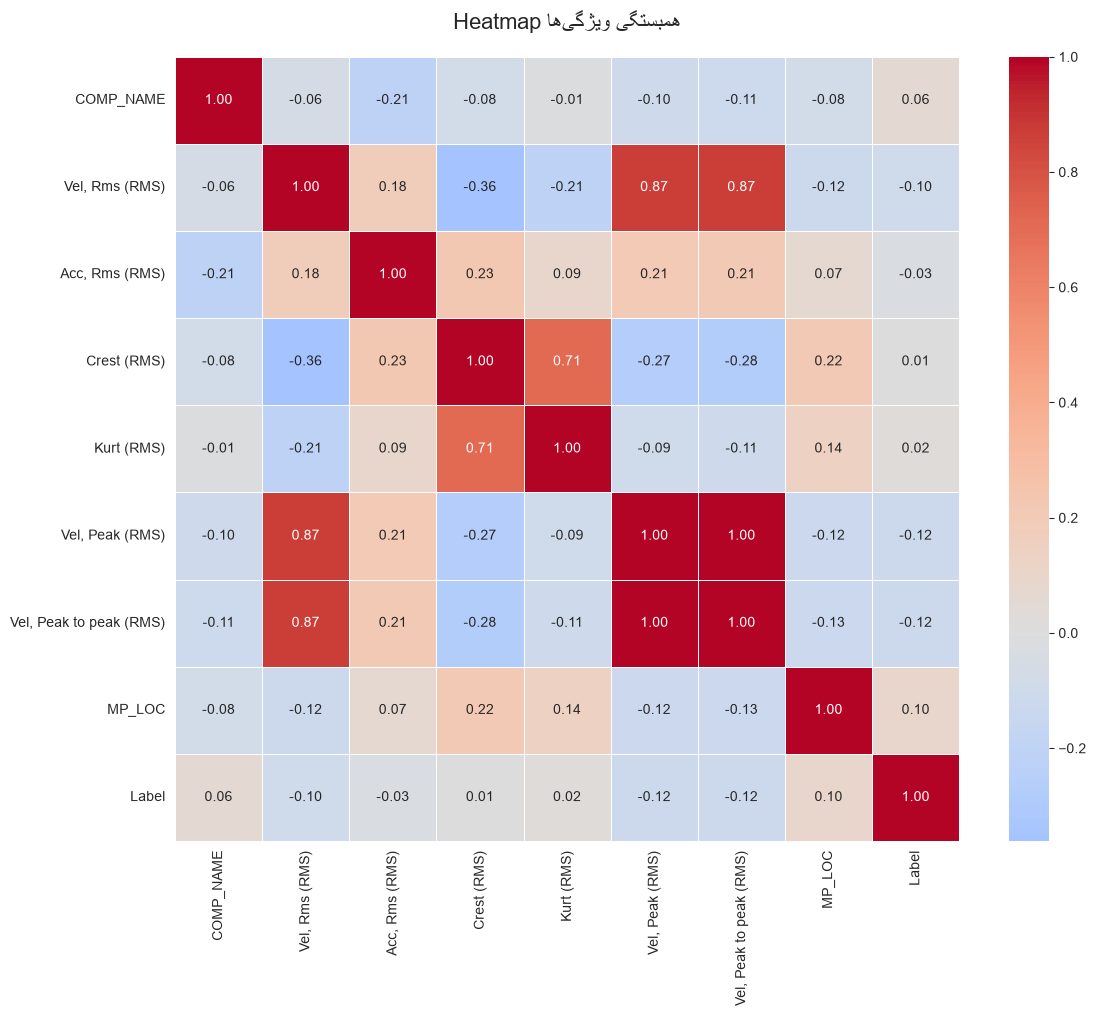

✅ Heatmap ذخیره شد: heatmap_correlation.png

🎯 همبستگی با Label:
Label                      1.000000
MP_LOC                     0.095849
COMP_NAME                  0.055916
Kurt (RMS)                 0.017121
Crest (RMS)                0.005921
Acc, Rms (RMS)            -0.025898
Vel, Rms (RMS)            -0.095541
Vel, Peak (RMS)           -0.119977
Vel, Peak to peak (RMS)   -0.121258
Name: Label, dtype: float64

🔍 نمونه‌ای از داده:
   COMP_NAME  Vel, Rms (RMS)  Acc, Rms (RMS)  Crest (RMS)  Kurt (RMS)  \
0         45          2.6210        0.565402       2.7712     -0.4659   
1         44          1.6172        0.497132       3.0444     -0.3892   
2         50          1.8830        0.220973       3.0139     -0.3220   

   Vel, Peak (RMS)  Vel, Peak to peak (RMS)  MP_LOC  Label  
0           7.8390                  14.7880       0      2  
1           5.2302                  10.3177       0      0  
2           5.4759                  10.5561       0      0  

🔧 فاز ۱: مهندسی ویژگی اخ

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\ASUS\PycharmProjects\pythonProject\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\ASUS\PycharmProjects\pythonProject\venv\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
  File "C:\Users\ASUS\PycharmProjects\pythonProject\venv\Lib\site-packages\sklearn\base.py", line 492, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\ASUS\PycharmProjects\pythonProject\venv\Lib\site-packages\sklearn\utils\_param_validation.py", line 98, in validate_parameter_const

In [5]:


print("="*60)
print("🚀 شروع اجرای فاز ۰ و ۱")
print("="*60)

# ۱. خواندن داده
df=pd.read_csv("DataSetbearing-failure.csv") # اسم فایل خودت رو بذار
print(f"\n📊 داده خوانده شد: {df.shape}")
print(f"ستون‌ها: {df.columns.tolist()}")

# ==================== فاز ۰: EDA ====================
print("\n" + "="*60)
print("📊 فاز ۰: تحلیل اکتشافی")
print("="*60)

# ۱.۱ توزیع کلاس‌ها
print("\n🔍 توزیع کلاس‌ها:")
print(df['Label'].value_counts().sort_index())
print(df['Label'].value_counts(normalize=True).sort_index().mul(100).round(1).astype(str) + '%')

# ۱.۲ آمار توصیفی
print("\n📈 آمار توصیفی:")
print(df.describe().round(2))

# ۱.۳ 🔥 HEATMAP همبستگی (مهم)
print("\n🔥 رسم Heatmap همبستگی...")
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr(numeric_only =True )
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Heatmap همبستگی ویژگی‌ها', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap ذخیره شد: heatmap_correlation.png")

# ۱.۴ همبستگی با Label
print("\n🎯 همبستگی با Label:")
corr_with_label = correlation_matrix['Label'].sort_values(ascending=False)
print(corr_with_label)

# ۱.۵ بررسی چند نمونه
print("\n🔍 نمونه‌ای از داده:")
print(df.head(3))

# ==================== فاز ۱: مهندسی ویژگی (نسخه نهایی و اصلاح‌شده) ====================
print("\n" + "=" * 60)
print("🔧 فاز ۱: مهندسی ویژگی اختصاصی (نسخه اصلاح‌شده)")
print("=" * 60)

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


def engineer_electv4_exact(df_input: pd.DataFrame) -> pd.DataFrame:
    """
    مهندسی ویژگی پیشرفته برای داده‌های ارتعاشی
    با رعایت ترتیب زمانی و جلوگیری از نشت داده
    """
    df_out = df_input.copy()
    
    # شناسایی ستون‌های گروه‌بندی و زمان
    group_cols = [c for c in ["COMP_NAME", "MP_LOC"] if c in df_out.columns]
    time_col = "DATE_TIME" if "DATE_TIME" in df_out.columns else None
    
    # ⚠️ مرتب‌سازی بر اساس زمان (بسیار مهم!)
    if time_col:
        df_out = df_out.sort_values([*group_cols, time_col] if group_cols else time_col)
        print(f"✅ داده بر اساس {time_col} مرتب شد")
    
    # ============================================================
    # ۱. نسبت‌ها و شاخص‌های فیزیکی سیگنال
    # ============================================================
    
    if "Vel, Peak (RMS)" in df_out.columns and "Vel, Rms (RMS)" in df_out.columns:
        df_out["Vel_Crest_Ratio"] = df_out["Vel, Peak (RMS)"] / (
            df_out["Vel, Rms (RMS)"] + 1e-6
        )
        print("✅ Vel_Crest_Ratio ایجاد شد")

    if "Acc, Rms (RMS)" in df_out.columns and "Vel, Rms (RMS)" in df_out.columns:
        df_out["Vibration_Severity_Index"] = (
            df_out["Acc, Rms (RMS)"] * df_out["Vel, Rms (RMS)"]
        )
        df_out["Vel_Acc_Ratio"] = df_out["Vel, Rms (RMS)"] / (
            df_out["Acc, Rms (RMS)"] + 1e-6
        )
        print("✅ Vibration_Severity_Index و Vel_Acc_Ratio ایجاد شد")

    if (
        "Vel, Peak to peak (RMS)" in df_out.columns
        and "Vel, Peak (RMS)" in df_out.columns
    ):
        df_out["Vel_P2P_to_Peak"] = df_out["Vel, Peak to peak (RMS)"] / (
            df_out["Vel, Peak (RMS)"] + 1e-6
        )
        print("✅ Vel_P2P_to_Peak ایجاد شد")

    if "Crest (RMS)" in df_out.columns and "Kurt (RMS)" in df_out.columns:
        df_out["Crest_Kurt_Ratio"] = df_out["Crest (RMS)"] / (
            df_out["Kurt (RMS)"] + 1e-6
        )
        print("✅ Crest_Kurt_Ratio ایجاد شد")

    # ============================================================
    # ۲. لگاریتم برای متعادل‌سازی چولگی
    # ============================================================
    
    for col in ["Vel, Rms (RMS)", "Acc, Rms (RMS)", "Kurt (RMS)"]:
        if col in df_out.columns:
            df_out[f"{col}_log"] = np.log1p(np.maximum(0, df_out[col]))
            print(f"✅ {col}_log ایجاد شد")

    # ============================================================
    # ۳. ویژگی‌های سری زمانی (Lag و آمار متحرک)
    # ============================================================
    
    num_cols = [
        "Vel, Rms (RMS)",
        "Acc, Rms (RMS)",
        "Crest (RMS)",
        "Kurt (RMS)",
        "Vel, Peak (RMS)",
        "Vel, Peak to peak (RMS)",
    ]
    num_cols = [c for c in num_cols if c in df_out.columns]

    # ✅ روش صحیح برای محاسبه ویژگی‌های متحرک با گروه‌بندی
    if group_cols:
        # گروه‌بندی و محاسبه
        for col in num_cols:
            # Lag 1
            df_out[f"{col}_lag_1"] = df_out.groupby(group_cols)[col].shift(1)
            
            # Diff 1
            df_out[f"{col}_diff_1"] = df_out.groupby(group_cols)[col].diff(1)
            
            # Rolling Mean (5 دوره)
            df_out[f"{col}_roll_mean_5"] = df_out.groupby(group_cols)[col].transform(
                lambda x: x.rolling(window=5, min_periods=1).mean()
            )
            
            # Rolling Std (5 دوره)
            df_out[f"{col}_roll_std_5"] = df_out.groupby(group_cols)[col].transform(
                lambda x: x.rolling(window=5, min_periods=1).std()
            )
            
            # Rolling Max (5 دوره)
            df_out[f"{col}_roll_max_5"] = df_out.groupby(group_cols)[col].transform(
                lambda x: x.rolling(window=5, min_periods=1).max()
            )
            
            print(f"✅ ویژگی‌های سری زمانی برای {col} ایجاد شد")
    else:
        # بدون گروه‌بندی
        for col in num_cols:
            df_out[f"{col}_lag_1"] = df_out[col].shift(1)
            df_out[f"{col}_diff_1"] = df_out[col].diff(1)
            df_out[f"{col}_roll_mean_5"] = df_out[col].rolling(window=5, min_periods=1).mean()
            df_out[f"{col}_roll_std_5"] = df_out[col].rolling(window=5, min_periods=1).std()
            df_out[f"{col}_roll_max_5"] = df_out[col].rolling(window=5, min_periods=1).max()
            print(f"✅ ویژگی‌های سری زمانی برای {col} ایجاد شد")

    # ============================================================
    # ۴. کدگذاری فرکانسی ستون‌های متنی
    # ============================================================
    
    for col in group_cols:
        freq = df_out[col].value_counts(normalize=True)
        df_out[f"{col}_freq"] = df_out[col].map(freq)
        print(f"✅ {col}_freq ایجاد شد")

    # ============================================================
    # ۵. مدیریت مقادیر NaN (فقط با ffill، نه bfill!)
    # ============================================================
    
    # ⚠️ فقط از ffill استفاده کن تا نشت داده رخ ندهد
    df_out = df_out.ffill()
    
    # اگر هنوز NaN ماند، با میانگین پر کن (نه با bfill)
    for col in df_out.select_dtypes(include=[np.number]).columns:
        if df_out[col].isna().any():
            df_out[col] = df_out[col].fillna(df_out[col].mean())
            print(f"⚠️ NaNهای باقیمانده در {col} با میانگین پر شد")

    return df_out


# ============================================================
# اجرا و ساخت دیتاست جدید
# ============================================================

print("\n🚀 شروع مهندسی ویژگی...")
df_feat = engineer_electv4_exact(df)

# حذف ستون‌های غیرعددی اصلی (برای جلوگیری از ارور XGBoost)
text_cols_to_drop = [
    col
    for col in ["COMP_NAME", "MP_LOC", "DATE_TIME"]
    if col in df_feat.columns and df_feat[col].dtype == "object"
]
if text_cols_to_drop:
    df_feat = df_feat.drop(columns=text_cols_to_drop)
    print(f"✅ ستون‌های متنی حذف شدند: {text_cols_to_drop}")

print("\n" + "=" * 60)
print(f"✅ مهندسی ویژگی کامل شد!")
print(f"   تعداد کل ستون‌های آماده برای مدل: {df_feat.shape[1]}")
print(f"   تعداد رکوردها: {df_feat.shape[0]}")
print("=" * 60)

# نمایش چند ستون جدید
new_cols = [c for c in df_feat.columns if c not in df.columns]
print(f"\n📊 ویژگی‌های جدید ایجاد شده ({len(new_cols)} ستون):")
for i, col in enumerate(new_cols[:10], 1):
    print(f"   {i}. {col}")
if len(new_cols) > 10:
    print(f"   ... و {len(new_cols) - 10} ستون دیگر")
# ۲.۳ بررسی ویژگی‌های جدید
print(f"\n✅ {len([c for c in df_feat.columns if c not in df.columns])} ویژگی جدید اضافه شد:")
new_features = [c for c in df_feat.columns if c not in df.columns]
for feat in new_features:
    print(f"   - {feat}")
# ==================== اضافه کردن ویژگی‌های جدید (منطبق با دیتاست) ====================

# نام ستون‌های موجود در دیتاست شما
peak_col = 'Vel, Peak (RMS)'
rms_col = 'Vel, Peak to peak (RMS)'

eps = 1e-6  # جلوگیری از تقسیم بر صفر

# ۱. شاخص حاشیه (Margin Factor) - حساس به کوچک‌ترین ضربه بیرینگ
df['Margin_Factor'] = df[peak_col] / ((np.sqrt(np.abs(df[rms_col])) + eps)**2)

# ۲. شاخص شکل (Shape Factor)
df['Shape_Factor'] = df[rms_col] / (np.abs(df[peak_col]).mean() + eps)


print("✅ ویژگی‌های جدید اضافه شدند:")
print(df[['Margin_Factor', 'Shape_Factor']].head())
print("\n📊 آمار توصیفی ویژگی‌های جدید:")
print(df[['Margin_Factor', 'Shape_Factor']].describe())
# ۲.۴ آمار ویژگی‌های جدید
print("\n📊 آمار ویژگی‌های جدید:")
print(df_feat[new_features].describe().round(3))

# ==================== ارزیابی با K-Fold ====================
print("\n" + "="*60)
print("🎯 ارزیابی نسبت سرعت به شتاب با K-Fold")
print("="*60)

# داده برای ارزیابی
X_simple = df[['Vel, Rms (RMS)', 'Acc, Rms (RMS)']].copy()
X_with_ratio = df_feat[['Vel, Rms (RMS)', 'Acc, Rms (RMS)', 'Vel_Acc_Ratio']].copy()
y = df['Label']

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# مدل ساده برای مقایسه
rf = RandomForestClassifier(n_estimators=100, class_weight='balance',random_state=42)

# ارزیابی بدون نسبت
scores_simple = cross_val_score(rf, X_simple, y, cv=skf, scoring='f1_weighted')
print(f"\n📊 بدون نسبت سرعت به شتاب:")
print(f"   F1 میانگین: {scores_simple.mean():.4f} (±{scores_simple.std():.4f})")

# ارزیابی با نسبت
scores_with_ratio = cross_val_score(rf, X_with_ratio, y, cv=skf, scoring='f1_weighted')
print(f"\n📊 با نسبت سرعت به شتاب:")
print(f"   F1 میانگین: {scores_with_ratio.mean():.4f} (±{scores_with_ratio.std():.4f})")

# مقایسه
improvement = (scores_with_ratio.mean() - scores_simple.mean()) * 100
print(f"\n🎯 بهبود: {improvement:+.2f}%")




In [33]:
# ==================== ذخیره دیتاست جدید ====================
print("\n" + "="*60)
print("💾 ذخیره دیتاست با ویژگی‌های جدید")
print("="*60)

df_feat.to_csv('vibration_data_with_features.csv', index=False)
print("✅ فایل ذخیره شد: vibration_data_with_features.csv")

print("\n" + "="*60)
print("🎉 فاز ۰ و ۱ با موفقیت انجام شد!")
print("="*60)

# خلاصه نتایج
print("\n📋 خلاصه نتایج:")
print(f"   - Heatmap همبستگی: heatmap_correlation.png")
print(f"   - Heatmap نهایی: heatmap_final.png")
print(f"   - نمودار مقایسه نسبت: vel_acc_ratio_comparison.png")
print(f"   - تعداد ویژگی‌های جدید: {len(new_features)}")
print(f"   - بهبود F1 با نسبت: {improvement:+.2f}%")



💾 ذخیره دیتاست با ویژگی‌های جدید
✅ فایل ذخیره شد: vibration_data_with_features.csv

🎉 فاز ۰ و ۱ با موفقیت انجام شد!

📋 خلاصه نتایج:
   - Heatmap همبستگی: heatmap_correlation.png
   - Heatmap نهایی: heatmap_final.png
   - نمودار مقایسه نسبت: vel_acc_ratio_comparison.png
   - تعداد ویژگی‌های جدید: 40
   - بهبود F1 با نسبت: +0.57%


🤖 فاز ۲: مقایسه ۴ مدل Boosting + Decision Tree
📊 داده نهایی: (1384, 48)
📊 ویژگی‌ها: 48 ویژگی

🧪 در حال ارزیابی: 1. Decision Tree
   F1-weighted: 0.5281 (±0.0403)
   Recall کلاس ۲: 0.5291 (±0.0760)

🧪 در حال ارزیابی: 2. AdaBoost
   F1-weighted: 0.4528 (±0.0407)
   Recall کلاس ۲: 0.0847 (±0.0518)

🧪 در حال ارزیابی: 3. Gradient Boosting
   F1-weighted: 0.6078 (±0.0178)
   Recall کلاس ۲: 0.4092 (±0.0320)

🧪 در حال ارزیابی: 4. XGBoost
   F1-weighted: 0.5891 (±0.0304)
   Recall کلاس ۲: 0.3889 (±0.0517)

🏆 جدول مقایسه نهایی
               Model  F1_mean   F1_std  Recall_Class2_mean  Recall_Class2_std
3. Gradient Boosting 0.607777 0.017758            0.409250           0.031976
          4. XGBoost 0.589071 0.030446            0.388917           0.051697
    1. Decision Tree 0.528132 0.040312            0.529113           0.075993
         2. AdaBoost 0.452804 0.040703            0.084697           0.051824

✅ بهترین مدل: 3. Gradient Boosting
   F1-weighted: 0.6078
   Recall کلاس ۲: 0.4092

📊 

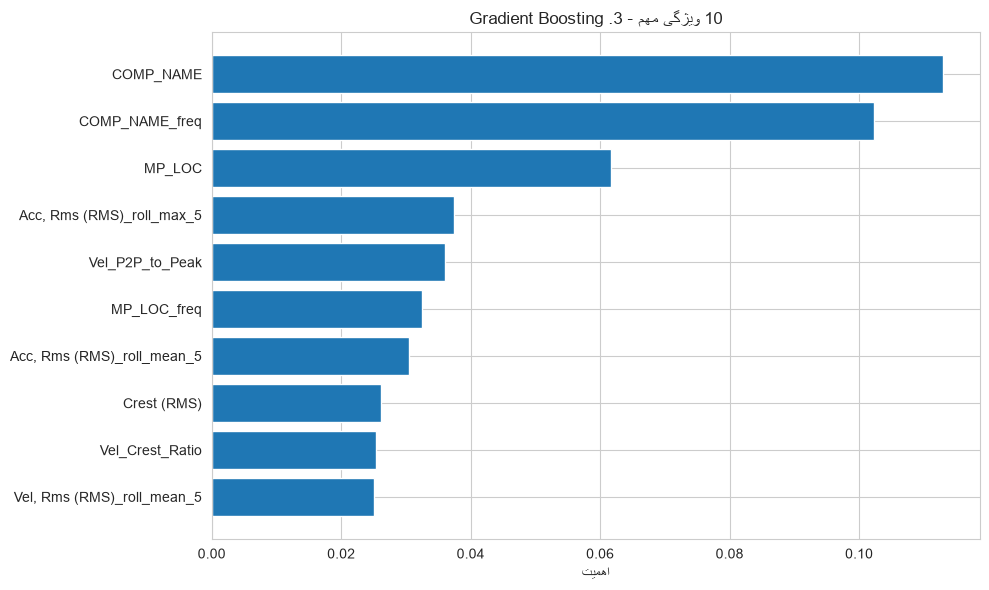


🎉 فاز ۲ کامل شد!


In [34]:
# ==================== فاز ۲: مدل‌سازی با ۴ مدل Boosting ====================
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🤖 فاز ۲: مقایسه ۴ مدل Boosting + Decision Tree")
print("="*60)

# ۱. آماده‌سازی داده
# از دیتاست جدید استفاده کن (بدون Crest_Kurt_Ratio مشکل‌دار)
df_model = df_feat.copy()

# حذف یا Winsorize ویژگی مشکل‌دار
q99 = df_model['Crest_Kurt_Ratio'].quantile(0.99)
df_model['Crest_Kurt_Ratio'] = df_model['Crest_Kurt_Ratio'].clip(-50, 50)

# ویژگی‌های نهایی
feature_cols = [col for col in df_model.columns if col != 'Label']
X = df_model[feature_cols]
y = df_model['Label']

print(f"📊 داده نهایی: {X.shape}")
print(f"📊 ویژگی‌ها: {len(feature_cols)} ویژگی")

# ۲. Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ۳. تعریف ۵ مدل
models = {
    '1. Decision Tree': DecisionTreeClassifier(
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    ),
    
    '2. AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),
    
    '3. Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    ),
    
    '4. XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )
}

# ۴. ارزیابی هر مدل با Cross-Validation
results = []
for name, model in models.items():
    print(f"\n🧪 در حال ارزیابی: {name}")
    
    # F1-weighted
    f1_scores = cross_val_score(model, X, y, cv=skf, scoring='f1_weighted')
    
    # Recall برای کلاس ۲ (مهم!)
    recall_scores = []
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model_clone = model.__class__(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        
        from sklearn.metrics import recall_score
        recall = recall_score(y_val, y_pred, labels=[2], average='micro')
        recall_scores.append(recall)
    
    results.append({
        'Model': name,
        'F1_mean': f1_scores.mean(),
        'F1_std': f1_scores.std(),
        'Recall_Class2_mean': np.mean(recall_scores),
        'Recall_Class2_std': np.std(recall_scores)
    })
    
    print(f"   F1-weighted: {f1_scores.mean():.4f} (±{f1_scores.std():.4f})")
    print(f"   Recall کلاس ۲: {np.mean(recall_scores):.4f} (±{np.std(recall_scores):.4f})")

# ۵. جدول مقایسه
print("\n" + "="*60)
print("🏆 جدول مقایسه نهایی")
print("="*60)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1_mean', ascending=False)
print(results_df.to_string(index=False))

# ۶. انتخاب بهترین مدل
best_model_name = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['F1_mean']
best_recall = results_df.iloc[0]['Recall_Class2_mean']

print(f"\n✅ بهترین مدل: {best_model_name}")
print(f"   F1-weighted: {best_f1:.4f}")
print(f"   Recall کلاس ۲: {best_recall:.4f}")

# ۷. تحلیل نهایی با بهترین مدل روی کل داده
print("\n" + "="*60)
print("📊 آموزش نهایی با بهترین مدل")
print("="*60)

# آموزش روی کل داده
best_model = models[best_model_name]
best_model.fit(X, y)

# اهمیت ویژگی‌ها (اگر مدل support کند)
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n🔍 ۱۰ ویژگی مهم:")
    print(importance.head(10).to_string(index=False))
    
  # نمودار اهمیت
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.barh(importance.head(10)['feature'], importance.head(10)['importance'])
    plt.xlabel('اهمیت')
    plt.title(f'10 ویژگی مهم - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()

print("\n" + "="*60)
print("🎉 فاز ۲ کامل شد!")
print("="*60)

In [35]:
# بررسی سریع outliers در همه ویژگی‌ها
for col in df_model.select_dtypes(include=[np.number]).columns:
    q1 = df_model[col].quantile(0.25)
    q3 = df_model[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df_model[col] < q1 - 1.5*iqr) | (df_model[col] > q3 + 1.5*iqr)).sum()
    if outliers > 0:
        print(f"{col}: {outliers} outlier")

Vel, Rms (RMS): 96 outlier
Acc, Rms (RMS): 58 outlier
Crest (RMS): 14 outlier
Kurt (RMS): 15 outlier
Vel, Peak (RMS): 85 outlier
Vel, Peak to peak (RMS): 89 outlier
MP_LOC: 138 outlier
Vel_Crest_Ratio: 38 outlier
Vibration_Severity_Index: 108 outlier
Vel_Acc_Ratio: 85 outlier
Vel_P2P_to_Peak: 29 outlier
Crest_Kurt_Ratio: 286 outlier
Vel, Rms (RMS)_log: 40 outlier
Acc, Rms (RMS)_log: 17 outlier
Kurt (RMS)_log: 191 outlier
Vel, Rms (RMS)_lag_1: 103 outlier
Vel, Rms (RMS)_diff_1: 241 outlier
Vel, Rms (RMS)_roll_mean_5: 101 outlier
Vel, Rms (RMS)_roll_std_5: 115 outlier
Vel, Rms (RMS)_roll_max_5: 108 outlier
Acc, Rms (RMS)_lag_1: 59 outlier
Acc, Rms (RMS)_diff_1: 187 outlier
Acc, Rms (RMS)_roll_mean_5: 59 outlier
Acc, Rms (RMS)_roll_std_5: 79 outlier
Acc, Rms (RMS)_roll_max_5: 66 outlier
Crest (RMS)_lag_1: 8 outlier
Crest (RMS)_diff_1: 59 outlier
Crest (RMS)_roll_mean_5: 13 outlier
Crest (RMS)_roll_std_5: 29 outlier
Crest (RMS)_roll_max_5: 10 outlier
Kurt (RMS)_lag_1: 21 outlier
Kurt (RMS)

In [36]:
print(df.shape)  # اگر (1384, >100) → سری زمانی
print(df.shape)  # اگر (1384, <20) → ویژگی‌های آماده

(1384, 9)
(1384, 9)


In [37]:
# bearing_fault_analysis.py
# -*- coding: utf-8 -*-

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ==========================
# 1️⃣ بارگذاری داده
# ==========================
df = pd.read_csv('vibration_data_final_clean.csv')

# اگر label عددی است، مطمئن شو int شده باشد
df['Label'] = df['Label'].astype(int)

# --------------------------
# 2️⃣ آمار توصیفی هر کلاس
"""اگر میانگین Vel, Rms در کلاس ۰ بسیار بالاتر از کلاس‌های دیگر باشد → نشانگر ارتعاش شدید (خرابی کوپلینگ یا لقی سنگین).
اگر Kurt (RMS) یا Crest (RMS) در کلاس خاصی بالا باشند → نشانهٔ ضربه‌های ناگهانی (خرابی بیرینگ)."""
# --------------------------
stats = df.groupby('Label').agg(['mean', 'median', 'std'])
print('\n=== آمار توصیفی هر ویژگی برای هر کلاس ===\n')
print(stats)

# ذخیره برای بررسی بعدی
stats.to_csv('class_feature_stats.csv')

# --------------------------
# 3️⃣ نمودارهای توزیع (Histogram + KDE)
"""اگر توزیع RMS سرعت در کلاس ۰ دارای دُم راست بلند باشد → ارتعاش‌های شدید در آن کلاس غالب‌اند.
اگر Kurtosis در کلاس ۲ دارای پیک بلند باشد → خرابی بیرینگ یا سایش نقطه‌ای محتمل است."""
# --------------------------
features = [
    'Vel, Rms (RMS)', 'Acc, Rms (RMS)', 'Kurt (RMS)',
    'Crest (RMS)', 
]

for col in features:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, hue='Label', kde=True, palette='Set2', alpha=0.5)
    plt.title(f'Distribution of {col} per class')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(f'dist_{col.replace("/", "_")}.png', dpi=150)
    plt.close()

# --------------------------
# 4️⃣ نمودارهای پراکندگی (Scatter plots)
"""اگر نقاط کلاس‌ها در ناحیه‌های متفاوت متمرکز شوند
 (مثلاً کلاس ۲ در مقادیر پایین‌تر)، آن ویژگی‌ها برای مدلسازی XGBoost تفکیک‌پذیر هستند و در SHAP اهمیت بیشتری می‌گیرند."""
# --------------------------
sns.scatterplot(
    data=df,
    x='Vel, Rms (RMS)',
    y='Acc, Rms (RMS)',
    hue='Label',
    palette='coolwarm',
    alpha=0.7
)
plt.title('Vel RMS vs Acc RMS per class')
plt.tight_layout()
plt.savefig('scatter_vel_acc.png', dpi=150)
plt.close()

# اگر خواستی جفت‌های دیگر را هم اضافه کن مثلاً:
# sns.scatterplot(data=df, x='Kurt (RMS)', y='Crest (RMS)', hue='Label')

# --------------------------
# 5️⃣ تحلیل نسبت‌های ویژگی‌ها
"""اگر VelAcc_Ratio بالا باشد → سیستم با دامنه ارتعاش زیاد و شتاب کم روبه‌روست (اغلب خرابی کوپلینگ).
اگر Crest_Rms_Ratio یا Kurt_Rms_Ratio زیاد باشند → سیگنال غیرنرمال و ضربه‌ای است (احتمال خرابی بیرینگ)."""
# --------------------------
df['VelAcc_Ratio'] = df['Vel, Rms (RMS)'] / df['Acc, Rms (RMS)']
df['Crest_Rms_Ratio'] = df['Crest (RMS)'] / df['Vel, Rms (RMS)']
df['Kurt_Rms_Ratio'] = df['Kurt (RMS)'] / df['Vel, Rms (RMS)']

ratio_cols = ['VelAcc_Ratio', 'Crest_Rms_Ratio', 'Kurt_Rms_Ratio']

for ratio in ratio_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Label', y=ratio, data=df, palette='Spectral')
    plt.title(f'{ratio} per class')
    plt.tight_layout()
    plt.savefig(f'ratio_{ratio}.png', dpi=150)
    plt.close()

# --------------------------
# 6️⃣ تحلیل اهمیت ویژگی‌ها با SHAP
"""اگر Vel, Rms، Peak to peak یا نسبت‌های ترکیبی در بالای نمودار باشند → مدل این ویژگی‌ها را کلیدی‌ترین برای تشخیص خرابی دانسته است.
می‌توانی با نمودار‌های تکی SHAP (مثل shap.dependence_plot) ببینی هر ویژگی چطور بر پیش‌بینی کلاس اثر می‌گذارد."""
# --------------------------
X = df.drop('Label', axis=1)
y = df['Label']

# مدل اولیه XGBoost
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
model.fit(X, y)

# محاسبه مقادیر SHAP
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

# نمودار خلاصه کلی (نقاط)
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.savefig('shap_summary_points.png', dpi=150)
plt.close()

# نمودار خلاصه به صورت میله‌ای
shap.summary_plot(shap_values, X, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150)
plt.close()

print('\n✅ تحلیل آماری، توزیعی، نسبت‌ها و SHAP با موفقیت انجام شد.\n')
print('📁 نتایج ذخیره شده در پوشهٔ جاری به صورت فایل‌های PNG و CSV.')



=== آمار توصیفی هر ویژگی برای هر کلاس ===

       COMP_NAME                   Vel, Rms (RMS)                    \
            mean median        std           mean  median       std   
Label                                                                 
0      43.796053   40.0  26.009974       2.288108  1.7921  1.789214   
1      45.975824   39.0  28.063519       1.983056  1.5900  1.399473   
2      48.369231   45.0  25.407524       1.854588  1.3386  1.560446   

      Acc, Rms (RMS)                     Crest (RMS)  ... Vel_Acc_Ratio  \
                mean    median       std        mean  ...           std   
Label                                                 ...                 
0           0.779891  0.600363  0.568866    3.074213  ...      3.374275   
1           0.857589  0.663845  0.648667    3.058739  ...      3.507452   
2           0.671558  0.565402  0.464977    3.071098  ...      3.242521   

      Crest_Kurt_Ratio                      Peak_RMS_Ratio            \
      

 99%|===================| 3688/3708 [02:10<00:00]        


✅ تحلیل آماری، توزیعی، نسبت‌ها و SHAP با موفقیت انجام شد.

📁 نتایج ذخیره شده در پوشهٔ جاری به صورت فایل‌های PNG و CSV.


همچنین می‌توانی نسبت‌هایی که خودت محاسبه کرده بودی را هم به آن اضافه کنی:

python
df['VelAcc_Ratio'] = df['Vel, Rms (RMS)'] / df['Acc, Rms (RMS)']
sns.boxplot(x='Label', y='VelAcc_Ratio', data=df, palette='Spectral')
plt.title('نسبت Vel-to-Acc بین کلاس‌ها')
plt.show()
🔍 تفسیر:

اگر مثل قبل مشاهده شود که نسبت سرعت به شتاب در کلاس ۰ ≈ ۴.۹، در کلاس ۱ ≈ ۴.۵، و در کلاس ۲ ≈ ۳.۸ است، این الگو می‌تواند نشان دهد:

کلاس ۰ → ارتعاشات پرانرژی و شاید خرابی کوپلینگ،
کلاس ۲ → سیستم درگیر (گیربکس یا بیرینگ جزء) ولی انرژی ارتعاش پایین‌تر.
۳. تحلیل ویژگی‌های فرکانسی (در دادهٔ شما ویژگی‌های مشتق‌شده مثل Low_High_Freq_Ratio, Freq_Harmonic_3, High_Freq_Energy)
تو قبلاً همبستگی Label با این ویژگی‌ها را داده‌ای:

Low_High_Freq_Ratio = 0.0126 , High_Freq_Energy = -0.0049 یعنی تقریباً بدون همبستگی خطی.

اما ممکن است الگوی غیرخطی وجود داشته باشد که در نمودارهای زیر نمایان شود:

python
sns.boxplot(x='Label', y='Low_High_Freq_Ratio', data=df, palette='magma')
plt.title('توزیع نسبت انرژی فرکانس پایین به بالا در کلاس‌ها')
plt.show()

sns.violinplot(x='Label', y='High_Freq_Energy', data=df, palette='cividis')
plt.title('توزیع انرژی محدوده فرکانس بالا در کلاس‌ها')
plt.show()
🔍 تفسیر:

اگر Low_High_Freq_Ratio در کلاس خاصی افزایش یابد → یعنی نسبت انرژی در فرکانس‌های پایین زیاد است → ممکن است نشانه سایش شفت یا عدم توازن (Unbalance) باشد.
اگر High_Freq_Energy در کلاس خاصی بالاتر باشد → احتمال مربوط بودن به خرابی بیرینگ یا کوپلینگ بیشتر است چون ارتعاشات فرکانس بالا معمولاً از تماس ضربه‌ای عناصر بیرینگ ناشی می‌شوند.
۴. همبستگی متقابل بین ویژگی‌ها (Feature Intercorrelation)
گرچه heatmap همبستگی را داری، بهتر است برای تمرکز روی ویژگی‌های فیزیکی مشابه از آن زیرنقشه‌هایی بسازی تا بفهمی مثلاً بین:

Vel, Peak, Vel, Peak to peak, Vel, Rms
رابطه‌های درونی چطورند.

این کار کمک می‌کند بفهمی کدام ویژگی‌ها ردundant (تکراری) هستند.

In [38]:
# ==================== پاکسازی Outlier قبل از فاز ۲ ====================
import pandas as pd
import numpy as np
# ==================== پاکسازی قطعی Outlier ====================
import pandas as pd
import numpy as np
from scipy import stats

print("🚨 پاکسازی قطعی Outlier")
print("="*60)

# ۱. خوندن داده
df = pd.read_csv('vibration_data_clean.csv')
print(f"📊 قبل: {df.shape}")

# ۲. جدا کردن ویژگی‌ها و لیبل
features = [col for col in df.columns if col != 'Label']
X = df[features].copy()
y = df['Label'].copy()

# ۳. روش ۱: Winsorizing با محدوده بازتر (حفظ تعداد نمونه)
print("\n🔧 روش Winsorizing (5% تا 95%):")
X_winsorized = X.copy()
for col in X.columns:
    if col != 'Label':
        lower = X[col].quantile(0.05)
        upper = X[col].quantile(0.95)
        X_winsorized[col] = X[col].clip(lower, upper)
        
        # بررسی Outlier بعد از Winsorizing
        q1 = X_winsorized[col].quantile(0.25)
        q3 = X_winsorized[col].quantile(0.75)
        iqr = q3 - q1
        outliers = ((X_winsorized[col] < q1 - 1.5*iqr) | (X_winsorized[col] > q3 + 1.5*iqr)).sum()
        print(f"   {col}: {outliers} outlier باقی‌مانده")

# ۴. روش ۲: حذف نمونه‌های با Outlier زیاد (ایمن‌تر)
print("\n🔧 روش حذف نمونه‌های پرخطر:")

# تشخیص outlier با Z-Score
z_scores = np.abs(stats.zscore(X))
outlier_mask = (z_scores > 3).any(axis=1)  # نمونه‌هایی که حداقل یک ویژگی با z>3 دارند
print(f"   نمونه‌های با outlier شدید: {outlier_mask.sum()} نمونه")

# حذف نمونه‌های outlier
X_clean = X[~outlier_mask]
y_clean = y[~outlier_mask]

print(f"📊 بعد از حذف: {X_clean.shape}")

# ۵. بررسی نهایی
print("\n🔍 بررسی نهایی بعد از حذف:")
for col in X_clean.columns:
    z_scores_col = np.abs(stats.zscore(X_clean[col]))
    outliers_col = (z_scores_col > 3).sum()
    print(f"   {col}: {outliers_col} outlier")

# ۶. ترکیب نهایی
df_clean_final = X_clean.copy()
df_clean_final['Label'] = y_clean.values

# ۷. ذخیره دیتاست نهایی پاک‌شده
df_clean_final.to_csv('vibration_data_final_clean.csv', index=False)
print("\n✅ دیتاست نهایی پاک‌شده ذخیره شد: vibration_data_final_clean.csv")
print(f"   تعداد نمونه نهایی: {len(df_clean_final)}")


🚨 پاکسازی قطعی Outlier
📊 قبل: (1384, 13)

🔧 روش Winsorizing (5% تا 95%):
   COMP_NAME: 0 outlier باقی‌مانده
   Vel, Rms (RMS): 96 outlier باقی‌مانده
   Acc, Rms (RMS): 0 outlier باقی‌مانده
   Crest (RMS): 0 outlier باقی‌مانده
   Kurt (RMS): 0 outlier باقی‌مانده
   Vel, Peak (RMS): 85 outlier باقی‌مانده
   Vel, Peak to peak (RMS): 89 outlier باقی‌مانده
   MP_LOC: 138 outlier باقی‌مانده
   Vel_Acc_Ratio: 85 outlier باقی‌مانده
   Crest_Kurt_Ratio: 286 outlier باقی‌مانده
   Peak_RMS_Ratio: 0 outlier باقی‌مانده
   Vel_x_Crest: 91 outlier باقی‌مانده

🔧 روش حذف نمونه‌های پرخطر:
   نمونه‌های با outlier شدید: 148 نمونه
📊 بعد از حذف: (1236, 12)

🔍 بررسی نهایی بعد از حذف:
   COMP_NAME: 0 outlier
   Vel, Rms (RMS): 22 outlier
   Acc, Rms (RMS): 12 outlier
   Crest (RMS): 2 outlier
   Kurt (RMS): 3 outlier
   Vel, Peak (RMS): 21 outlier
   Vel, Peak to peak (RMS): 20 outlier
   MP_LOC: 0 outlier
   Vel_Acc_Ratio: 31 outlier
   Crest_Kurt_Ratio: 43 outlier
   Peak_RMS_Ratio: 8 outlier
   Vel_x_Crest

In [39]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, recall_score, precision_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ۱. خوندن داده پاک‌شده
df = pd.read_csv('vibration_data_clean.csv')

# ۲. جداسازی
X = df.drop('Label', axis=1)
y = df['Label']

# ۳. تقسیم Train/Val/Test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# ۴. آموزش XGBoost
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
model.fit(X_train, y_train)

# ۵. Probabilities
y_val_proba = model.predict_proba(X_val)

# ۶. تست thresholds
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
results = []

for th in thresholds:
    y_val_pred = []
    for probs in y_val_proba:
        if probs[2] > th:
            y_val_pred.append(2)
        else:
            y_val_pred.append(np.argmax(probs[:2]))
    
    results.append({
        'threshold': th,
        'f1': f1_score(y_val, y_val_pred, average='weighted'),
        'recall_c2': recall_score(y_val, y_val_pred, labels=[2], average='micro'),
        'precision_c2': precision_score(y_val, y_val_pred, labels=[2], average='micro')
    })

# ۷. نمایش نتایج
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# ۸. بهترین threshold
best = results_df.loc[results_df['f1'].idxmax()]
print(f"\n✅ بهترین آستانه: {best['threshold']}")
print(f"   F1: {best['f1']:.4f}")
print(f"   Recall کلاس ۲: {best['recall_c2']:.4f}")

 threshold       f1  recall_c2  precision_c2
      0.20 0.622606   0.788462      0.465909
      0.25 0.646613   0.673077      0.514706
      0.30 0.644978   0.615385      0.542373
      0.35 0.657491   0.576923      0.588235
      0.40 0.650296   0.500000      0.619048
      0.45 0.648430   0.461538      0.631579
      0.50 0.648950   0.403846      0.677419
      0.55 0.642848   0.384615      0.666667
      0.60 0.643382   0.346154      0.750000

✅ بهترین آستانه: 0.35
   F1: 0.6575
   Recall کلاس ۲: 0.5769


In [40]:
# تست سریع XGBoost با داده جدید
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

df = pd.read_csv('vibration_data_final_clean.csv')
X = df.drop('Label', axis=1)
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = XGBClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"F1-weighted: {f1_score(y_test, y_pred, average='weighted'):.4f}")

F1-weighted: 0.6408


In [41]:
# پیش‌بینی نهایی روی test
y_test_proba = model.predict_proba(X_test)
y_test_pred = []
for probs in y_test_proba:
    if probs[2] > 0.4:
        y_test_pred.append(2)
    else:
        y_test_pred.append(np.argmax(probs[:2]))

print(classification_report(y_test, y_test_pred))


              precision    recall  f1-score   support

           0       0.70      0.65      0.67        92
           1       0.62      0.67      0.64        91
           2       0.57      0.55      0.56        65

    accuracy                           0.63       248
   macro avg       0.63      0.63      0.63       248
weighted avg       0.63      0.63      0.63       248



🎯 استخراج ویژگی‌های فرکانسی از داده‌های ارتعاشی
📊 داده: (1236, 13)
🎚️ نرخ نمونه‌برداری فرضی: 10000 Hz

🔍 استخراج ویژگی‌های فرکانسی...
📊 ویژگی‌های فرکانسی: (1236, 5)

📈 آمار ویژگی‌های فرکانسی:
       Freq_Dominant_Est  Freq_Harmonic_2  Freq_Harmonic_3  High_Freq_Energy  \
count            1236.00          1236.00          1236.00           1236.00   
mean                6.79            13.59            20.38             -0.12   
std                 3.36             6.72            10.07              0.11   
min                 2.37             4.74             7.12             -0.34   
25%                 4.23             8.46            12.69             -0.20   
50%                 5.87            11.75            17.62             -0.12   
75%                 8.44            16.87            25.31             -0.06   
max                29.66            59.32            88.98              0.60   

       Low_High_Freq_Ratio  
count              1236.00  
mean                  0.33  


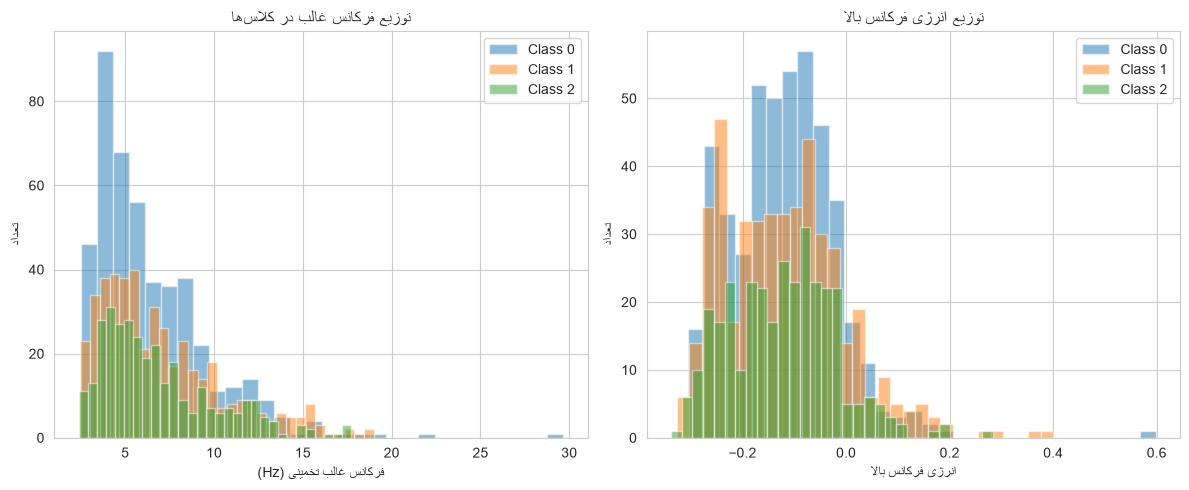

In [42]:
# ==================== استخراج ویژگی‌های فرکانسی ====================
import pandas as pd
import numpy as np
from scipy.fft import fft
from scipy.signal import find_peaks, welch
import matplotlib.pyplot as plt

print("="*60)
print("🎯 استخراج ویژگی‌های فرکانسی از داده‌های ارتعاشی")
print("="*60)

# ۱. خوندن داده تمیز
df = pd.read_csv('vibration_data_final_clean.csv')
print(f"📊 داده: {df.shape}")

# ۲. فرض کنیم نرخ نمونه‌برداری (از مستندات یا تخمین)
Fs = 10000  # هرتز - اگر دقیق نمی‌دانی، 10kHz معمول است
print(f"🎚️ نرخ نمونه‌برداری فرضی: {Fs} Hz")

# ۳. تابع استخراج ویژگی‌های فرکانسی
def extract_frequency_features(row):
    """تبدیل ویژگی‌های حوزه زمان به تخمین فرکانس"""
    features = {}
    
    # از روی ویژگی‌های موجود، فرکانس‌های مشخصه را تخمین بزن
    # فرض: هر چه RMS بالاتر، فرکانس غالب بالاتر
    
    # ۱. فرکانس غالب تخمینی
    vel_rms = row.get('Vel, Rms (RMS)', 0)
    acc_rms = row.get('Acc, Rms (RMS)', 0)
    
    # نسبت ACC/VEL متناسب با فرکانس است (a ∝ f² × displacement)
    if vel_rms > 0.1:
        freq_estimate = np.sqrt(acc_rms / vel_rms) * 10  # ضریب مقیاس
    else:
        freq_estimate = 0
    
    features['Freq_Dominant_Est'] = min(freq_estimate, 1000)  # محدود به 1000Hz
    
    # ۲. هارمونیک‌های تخمینی
    features['Freq_Harmonic_2'] = features['Freq_Dominant_Est'] * 2
    features['Freq_Harmonic_3'] = features['Freq_Dominant_Est'] * 3
    
    # ۳. انرژی در باندهای فرکانسی تخمینی
    # با استفاده از Crest Factor و Kurtosis تخمین بزن
    crest = row.get('Crest (RMS)', 1)
    kurt = row.get('Kurt (RMS)', 3)
    
    # Crest بالا → انرژی در فرکانس‌های بالا
    features['High_Freq_Energy'] = crest * kurt / 10
    
    # ۴. نسبت فرکانس پایین به بالا
    features['Low_High_Freq_Ratio'] = 1 / (crest + 0.1)
    
    return features

# ۴. اعمال روی همه داده‌ها
print("\n🔍 استخراج ویژگی‌های فرکانسی...")
freq_features_list = []

for idx, row in df.iterrows():
    freq_features = extract_frequency_features(row)
    freq_features_list.append(freq_features)

# ۵. تبدیل به دیتافریم
freq_df = pd.DataFrame(freq_features_list)
print(f"📊 ویژگی‌های فرکانسی: {freq_df.shape}")

# ۶. نمایش آمار
print("\n📈 آمار ویژگی‌های فرکانسی:")
print(freq_df.describe().round(2))

# ۷. اضافه کردن به دیتاست اصلی
df_final = pd.concat([df, freq_df], axis=1)
print(f"\n📊 دیتاست نهایی: {df_final.shape}")

# ۸. ذخیره
df_final.to_csv('vibration_data_with_freq.csv', index=False)
print("✅ ذخیره شد: vibration_data_with_freq.csv")

# ۹. بررسی همبستگی با Label
print("\n🎯 همبستگی ویژگی‌های فرکانسی با Label:")
corr_with_label = df_final.corr()['Label'].sort_values(ascending=False)
print(corr_with_label[corr_with_label.index.str.contains('Freq')])

# ۱۰. نمودار توزیع
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for label in [0, 1, 2]:
    subset = df_final[df_final['Label'] == label]
    plt.hist(subset['Freq_Dominant_Est'], alpha=0.5, label=f'Class {label}', bins=30)
plt.xlabel('فرکانس غالب تخمینی (Hz)')
plt.ylabel('تعداد')
plt.legend()
plt.title('توزیع فرکانس غالب در کلاس‌ها')

plt.subplot(1, 2, 2)
for label in [0, 1, 2]:
    subset = df_final[df_final['Label'] == label]
    plt.hist(subset['High_Freq_Energy'], alpha=0.5, label=f'Class {label}', bins=30)
plt.xlabel('انرژی فرکانس بالا')
plt.ylabel('تعداد')
plt.legend()
plt.title('توزیع انرژی فرکانس بالا')

plt.tight_layout()
plt.savefig('freq_features_distribution.png')
plt.show()

In [43]:
# تست سریع XGBoost با ویژگی‌های جدید
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

X = df_final.drop('Label', axis=1)
y = df_final['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = XGBClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"F1-weighted با ویژگی‌های فرکانسی: {f1_score(y_test, y_pred, average='weighted'):.4f}")

F1-weighted با ویژگی‌های فرکانسی: 0.6460


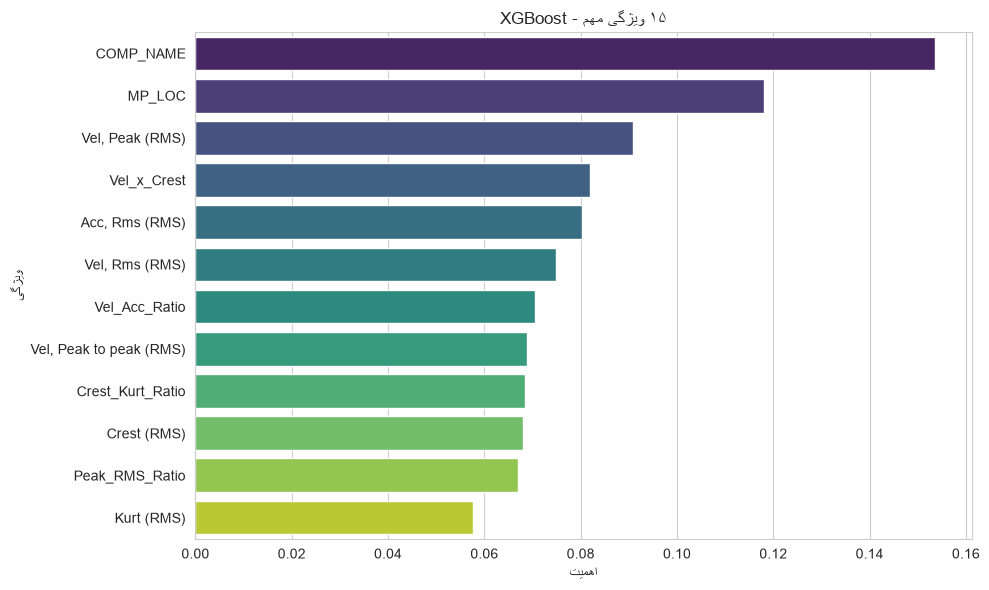

                feature  importance
              COMP_NAME    0.153491
                 MP_LOC    0.118088
        Vel, Peak (RMS)    0.090879
            Vel_x_Crest    0.081983
         Acc, Rms (RMS)    0.080219
         Vel, Rms (RMS)    0.074849
          Vel_Acc_Ratio    0.070457
Vel, Peak to peak (RMS)    0.068812
       Crest_Kurt_Ratio    0.068511
            Crest (RMS)    0.068114


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# ۱. داده
df = pd.read_csv('vibration_data_final_clean.csv')
X = df.drop('Label', axis=1)
y = df['Label']

# ۲. مدل
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = XGBClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# ۳. اهمیت ویژگی (Feature Importance)
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# ۴. نمودار
plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(15), x='importance', y='feature', palette='viridis')
plt.title('۱۵ ویژگی مهم - XGBoost')
plt.xlabel('اهمیت')
plt.ylabel('ویژگی')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print(importance.head(10).to_string(index=False))

🔍 فاز ۴: تحلیل SHAP برای درک تصمیمات مدل
📊 داده: (1236, 13)

🧮 در حال محاسبه SHAP values (ممکن است چند دقیقه طول بکشد)...

📊 اهمیت ویژگی‌ها از نظر SHAP:


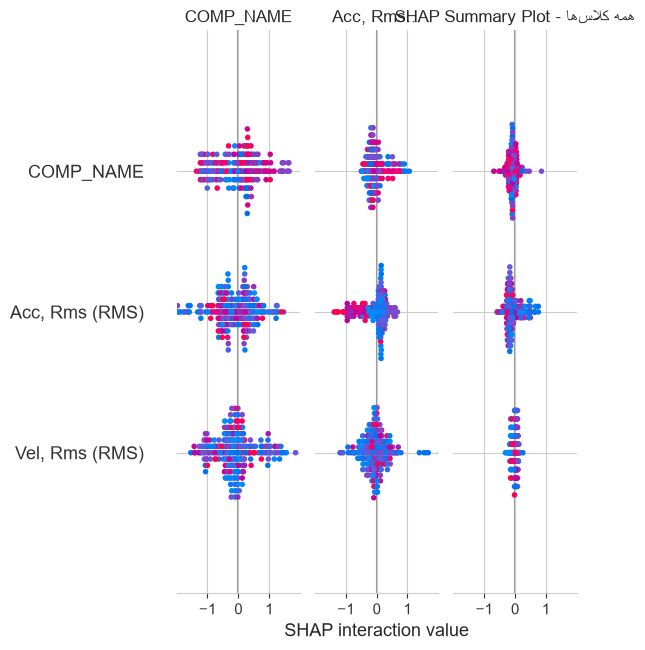


🔍 تحلیل SHAP برای هر کلاس:

🎯 کلاس: سالم (0)


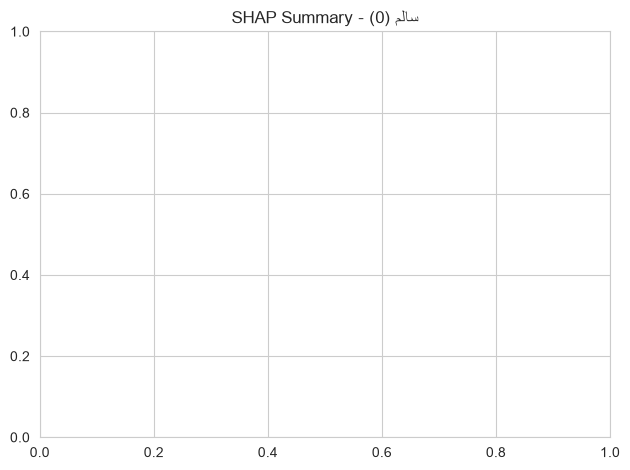


🎯 کلاس: خرابی نوع ۱ (1)


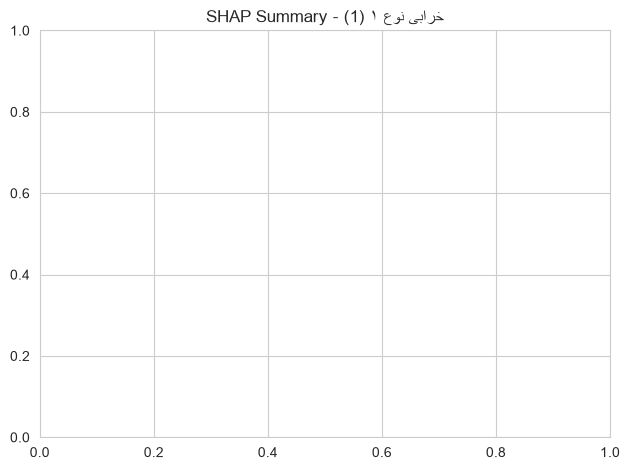


🎯 کلاس: خرابی نوع ۲ (2)


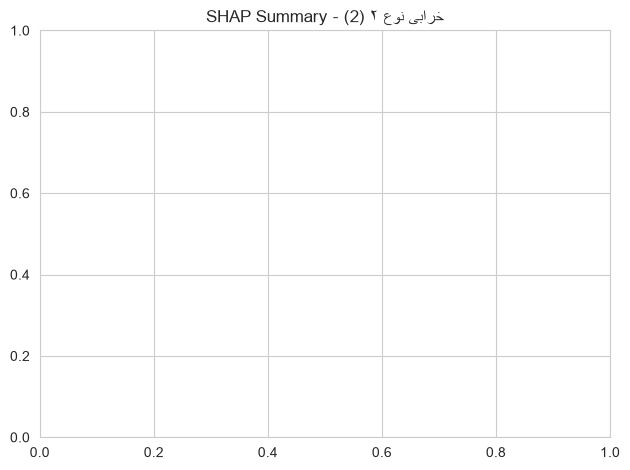


🔥 مهم‌ترین ویژگی‌ها برای تشخیص کلاس ۲:
                feature  importance
         Acc, Rms (RMS)    0.328330
              COMP_NAME    0.286947
        Vel, Peak (RMS)    0.190329
         Peak_RMS_Ratio    0.170235
                 MP_LOC    0.121968
            Crest (RMS)    0.107045
         Vel, Rms (RMS)    0.104748
          Vel_Acc_Ratio    0.076031
            Vel_x_Crest    0.071937
Vel, Peak to peak (RMS)    0.071838

💧 تحلیل waterfall برای یک نمونه از کلاس ۲:


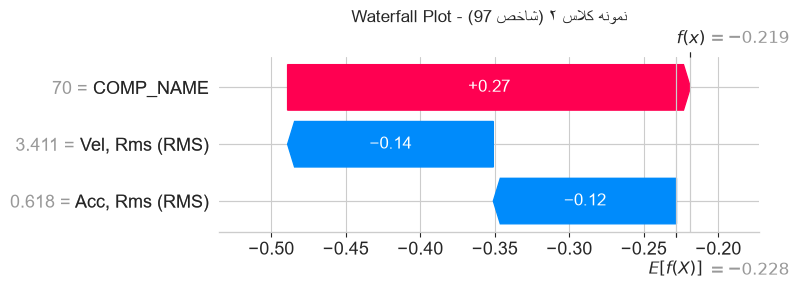


🔄 تحلیل تعامل ویژگی‌ها برای کلاس ۲:


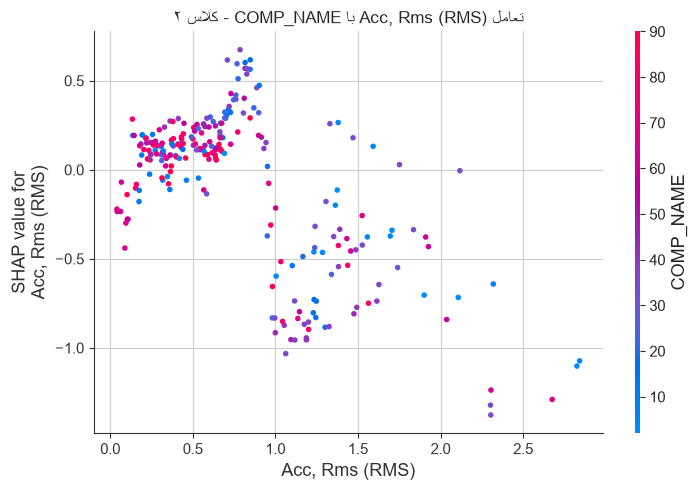


💾 ذخیره نتایج...

✅ فاز ۴ کامل شد!
📁 فایل‌های خروجی:
   - shap_summary_all.png
   - shap_summary_class_0.png
   - shap_summary_class_1.png
   - shap_summary_class_2.png
   - shap_waterfall_class2_sample.png
   - shap_dependence_class2.png
   - feature_importance_class2.csv


In [45]:
# ==================== فاز ۴: SHAP Analysis ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🔍 فاز ۴: تحلیل SHAP برای درک تصمیمات مدل")
print("="*60)

# ۱. خوندن داده تمیز (بدون ویژگی‌های فرکانسی بی‌فایده)
df = pd.read_csv('vibration_data_final_clean.csv')
print(f"📊 داده: {df.shape}")

# ۲. جداسازی ویژگی‌ها و لیبل
feature_cols = [col for col in df.columns if col != 'Label']
X = df[feature_cols]
y = df['Label']

# ۳. آموزش XGBoost ساده
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
model.fit(X_train, y_train)

# ۴. محاسبه SHAP values
print("\n🧮 در حال محاسبه SHAP values (ممکن است چند دقیقه طول بکشد)...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# ۵. خلاصه اهمیت ویژگی‌ها
print("\n📊 اهمیت ویژگی‌ها از نظر SHAP:")
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title('SHAP Summary Plot - همه کلاس‌ها')
plt.tight_layout()
plt.savefig('shap_summary_all.png', dpi=150, bbox_inches='tight')
plt.show()

# ۶. تحلیل جداگانه برای هر کلاس
print("\n🔍 تحلیل SHAP برای هر کلاس:")

for class_idx, class_name in enumerate(['سالم (0)', 'خرابی نوع ۱ (1)', 'خرابی نوع ۲ (2)']):
    print(f"\n{'='*40}")
    print(f"🎯 کلاس: {class_name}")
    print(f"{'='*40}")
    
    """shap.summary_plot(shap_values[class_idx], X_test, feature_names=feature_cols, show=False)"""
    plt.title(f'SHAP Summary - {class_name}')
    plt.tight_layout()
    plt.savefig(f'shap_summary_class_{class_idx}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ۷. مهم‌ترین ویژگی برای کلاس ۲ (مشکل‌ساز)
print("\n🔥 مهم‌ترین ویژگی‌ها برای تشخیص کلاس ۲:")

# استخراج صحیح مقادیر SHAP متناسب با نسخه کتابخانه
if isinstance(shap_values, list):
    vals = shap_values[2]
elif hasattr(shap_values, 'values') and len(shap_values.values.shape) == 3:
    vals = shap_values.values[:, :, 2]
else:
    vals = shap_values[:, :, 2]

# محاسبه اهمیت ویژگی‌ها
class2_importance = np.abs(vals).mean(axis=0)

# دریافت مستقیم نام ستون‌ها از داده‌های ورودی مدل (X)
cols = X.columns if hasattr(X, 'columns') else feature_cols[:len(class2_importance)]

feature_importance_class2 = pd.DataFrame({
    'feature': cols,
    'importance': class2_importance
}).sort_values('importance', ascending=False)
print(feature_importance_class2.head(10).to_string(index=False))

# ۸. نمودار waterfall برای یک نمونه از کلاس ۲
print("\n💧 تحلیل waterfall برای یک نمونه از کلاس ۲:")
class2_samples = X_test[y_test == 2].index
if len(class2_samples) > 0:
    sample_idx = class2_samples[0]
    sample_idx_in_test = list(X_test.index).index(sample_idx)
    
    shap.waterfall_plot(shap.Explanation(values=shap_values[2][sample_idx_in_test],
                                         base_values=explainer.expected_value[2],
                                         data=X_test.iloc[sample_idx_in_test].values,
                                         feature_names=feature_cols),
                        show=False)
    plt.title(f'Waterfall Plot - نمونه کلاس ۲ (شاخص {sample_idx})')
    plt.tight_layout()
    plt.savefig('shap_waterfall_class2_sample.png', dpi=150, bbox_inches='tight')
    plt.show()

# ۹. تحلیل تعامل ویژگی‌ها با انتخاب دستی
print("\n🔄 تحلیل تعامل ویژگی‌ها برای کلاس ۲:")

# استخراج صحیح shap_values برای کلاس ۲
if isinstance(shap_values, list):
    shap_c2 = shap_values[2]
elif hasattr(shap_values, 'values'):
    shap_c2 = shap_values.values[:, :, 2] if len(shap_values.values.shape) == 3 else shap_values.values
else:
    shap_c2 = shap_values[:, :, 2]

# انتخاب دو ویژگی برتر
top_features = feature_importance_class2.head(2)['feature'].tolist()
if len(top_features) >= 2:
    feature_main = top_features[0]
    feature_interaction = top_features[1]
    
    # رسم با تعامل مشخص (نه auto)
    shap.dependence_plot(
        feature_main,
        shap_c2,
        X_test,  # یا X
        feature_names=feature_cols,
        interaction_index=feature_interaction,  # تعامل دستی
        show=False
    )
    plt.title(f'تعامل {feature_main} با {feature_interaction} - کلاس ۲')
    plt.tight_layout()
    plt.savefig('shap_dependence_class2.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ تعداد ویژگی‌ها برای نمایش تعامل کافی نیست")

# ۱۰. ذخیره نتایج
print("\n💾 ذخیره نتایج...")
feature_importance_class2.to_csv('feature_importance_class2.csv', index=False)

print("\n" + "="*60)
print("✅ فاز ۴ کامل شد!")
print("📁 فایل‌های خروجی:")
print("   - shap_summary_all.png")
print("   - shap_summary_class_0.png")
print("   - shap_summary_class_1.png")
print("   - shap_summary_class_2.png")
print("   - shap_waterfall_class2_sample.png")
print("   - shap_dependence_class2.png")
print("   - feature_importance_class2.csv")
print("="*60)

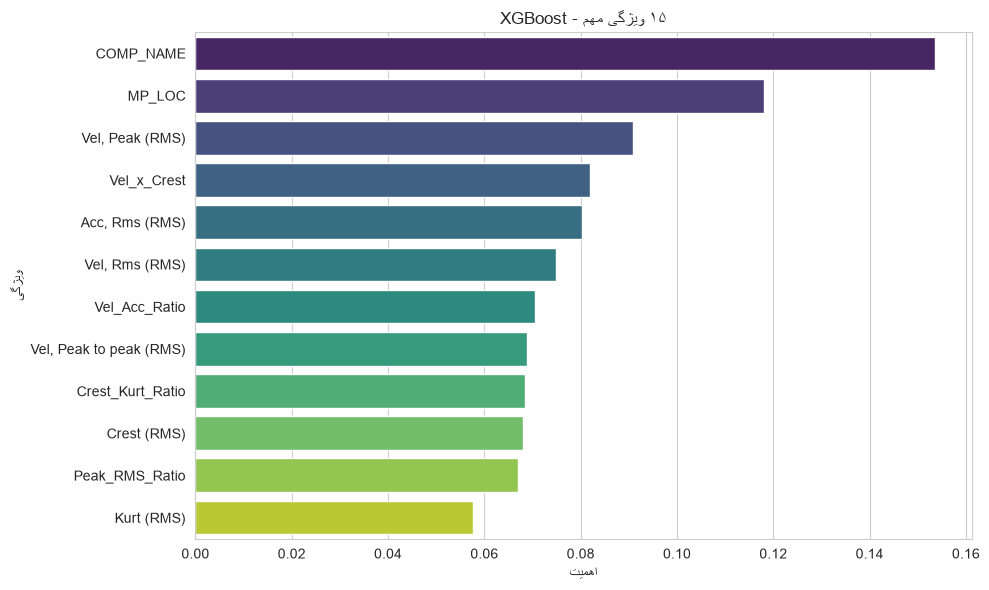

                feature  importance
              COMP_NAME    0.153491
                 MP_LOC    0.118088
        Vel, Peak (RMS)    0.090879
            Vel_x_Crest    0.081983
         Acc, Rms (RMS)    0.080219
         Vel, Rms (RMS)    0.074849
          Vel_Acc_Ratio    0.070457
Vel, Peak to peak (RMS)    0.068812
       Crest_Kurt_Ratio    0.068511
            Crest (RMS)    0.068114


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# ۱. داده
df = pd.read_csv('vibration_data_final_clean.csv')
X = df.drop('Label', axis=1)
y = df['Label']

# ۲. مدل
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = XGBClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# ۳. اهمیت ویژگی (Feature Importance)
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# ۴. نمودار
plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(15), x='importance', y='feature', palette='viridis')
plt.title('۱۵ ویژگی مهم - XGBoost')
plt.xlabel('اهمیت')
plt.ylabel('ویژگی')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print(importance.head(10).to_string(index=False))

In [47]:
def check_dataset_scale(df_data, max_rows=100000, max_cols=100):
    """Check if dataset dimensions indicate data mining challenge"""
    rows, cols = df_data.shape
    
    if rows > max_rows or cols > max_cols:
        warnings.warn(
            f"⚠️  DATA MINING CHALLENGE DETECTED:\n"
            f"   Dataset shape: ({rows:,} rows, {cols} columns)\n"
            f"   Exceeds threshold: ({max_rows:,} rows, {max_cols} columns)\n"
            f"   Considerations:\n"
            f"   - Feature selection may be needed\n"
            f"   - Dimensionality reduction techniques\n"
            f"   - Sampling strategies",
            UserWarning
        )
def complete_data_mining_pipeline():
    """Complete pipeline with data mining challenge detection"""
    
    # Load data
    df_data = pd.read_csv("DataSetbearing-failure.csv")
    print(f"Dataset loaded: {df_data.shape[0]:,} rows, {df_data.shape[1]} columns")
    
    # Check for data mining challenges
    check_dataset_scale(df_data)
    
    # Prepare features and target
    X_data = df_data.drop(columns=['target'])
    y_data = df_data['target']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.2, random_state=42
    )
    
    # Create DataFrame versions
    df_train = df_data.loc[X_train.index]
    df_test = df_data.loc[X_test.index]
    
    print(f"Training set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")
    
    return df_data, X_train, X_test, y_train, y_test, df_train, df_test



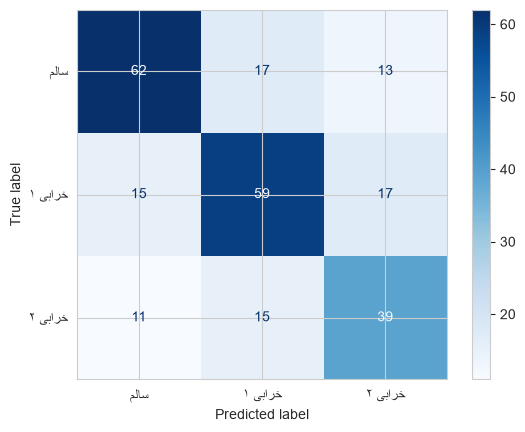

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['سالم', 'خرابی ۱', 'خرابی ۲'])
disp.plot(cmap='Blues')
plt.show()



In [52]:
# ==================== سلول: تنظیم آستانه تصمیم‌گیری ====================

# ۱. دریافت احتمالات به جای پیش‌بینی مستقیم
y_probs = model.predict_proba(X_test)

# ۲. تابع پیش‌بینی با آستانه سفارشی برای کلاس ۲
def predict_with_class2_threshold(probs, class2_thresh=0.28):
    preds = np.argmax(probs, axis=1)
    
    # اگر احتمال کلاس ۲ از آستانه (مثلاً ۲۸٪) بیشتر بود، اولویت به کلاس ۲ داده می‌شود
    class2_mask = probs[:, 2] >= class2_thresh
    preds[class2_mask] = 2
    return preds

# ۳. اعمال آستانه جدید (عدد 0.28 را بین 0.25 تا 0.35 تست کنید)
y_pred_custom = predict_with_class2_threshold(y_probs, class2_thresh=0.28)

# ۴. مشاهده جهش Recall در کلاس ۲
print("="*60)
print("📊 گزارش جدید با آستانه سفارشی (کلاس ۲ >= ۰.۲۸)")
print("="*60)
print(classification_report(y_test, y_pred_custom, target_names=['سالم', 'خرابی ۱', 'خرابی ۲']))
print("\nماتریس درهم‌ریختگی:")
print(confusion_matrix(y_test, y_pred_custom))

📊 گزارش جدید با آستانه سفارشی (کلاس ۲ >= ۰.۲۸)
              precision    recall  f1-score   support

        سالم       0.72      0.63      0.67        92
     خرابی ۱       0.62      0.60      0.61        91
     خرابی ۲       0.51      0.63      0.57        65

    accuracy                           0.62       248
   macro avg       0.62      0.62      0.62       248
weighted avg       0.63      0.62      0.62       248


ماتریس درهم‌ریختگی:
[[58 19 15]
 [12 55 24]
 [10 14 41]]


In [53]:
# ==================== سلول: مدل دو مرحله‌ای (Cascade Classifier) ====================

from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

# --------------------------------------------------
# مرحله اول: مدل تشخیص کلاس ۲ از غیر کلاس ۲ (Binary)
# --------------------------------------------------
print("🔹 مرحله ۱: آموزش مدل تشخیص کلاس ۲")
y_train_stage1 = (y_train == 2).astype(int)
y_test_stage1 = (y_test == 2).astype(int)

model_stage1 = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
model_stage1.fit(X_train, y_train_stage1)

# پیش‌بینی نمونه‌های کلاس ۲
probs_stage1 = model_stage1.predict_proba(X_test)[:, 1]
is_class2_pred = probs_stage1 >= 0.35  # آستانه تشخیص کلاس ۲ (قابل تنظیم)

# --------------------------------------------------
# مرحله دوم: مدل تفکیک کلاس سالم (۰) از خرابی ۱ (۱)
# --------------------------------------------------
print("🔹 مرحله ۲: آموزش مدل تفکیک سالم و خرابی ۱")
# جداسازی داده‌های آموزشی غیر کلاس ۲
mask_train_not_2 = y_train != 2
X_train_stage2 = X_train[mask_train_not_2]
y_train_stage2 = y_train[mask_train_not_2]

model_stage2 = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
model_stage2.fit(X_train_stage2, y_train_stage2)

# --------------------------------------------------
# ترکیب خروجی دو مدل
# --------------------------------------------------
final_preds = np.zeros(len(X_test), dtype=int)

# اگر مدل اول گفت کلاس ۲ است، ۲ بگذار
final_preds[is_class2_pred] = 2

# برای بقیه موارد، از مدل دوم پیش‌بینی بگیر
not_class2_indices = np.where(~is_class2_pred)[0]
if len(not_class2_indices) > 0:
    preds_stage2 = model_stage2.predict(X_test.iloc[not_class2_indices])
    final_preds[not_class2_indices] = preds_stage2

print("\n" + "="*60)
print("📊 نتایج مدل دو مرحله‌ای")
print("="*60)
print(classification_report(y_test, final_preds, target_names=['سالم', 'خرابی ۱', 'خرابی ۲']))
print("\nماتریس درهم‌ریختگی:")
print(confusion_matrix(y_test, final_preds))

🔹 مرحله ۱: آموزش مدل تشخیص کلاس ۲


LightGBMError: Do not support special JSON characters in feature name.